# Personalized Recommendation and Customer Churn Prediction

# 1. Introduction

Modern e-commerce platforms operate in an environment defined by scale, competition, and rapidly evolving consumer behavior. Marketplaces such as Amazon.com, Inc. host vast product catalogs and serve millions of users daily. In such ecosystems, two strategic challenges dominate digital commerce:

1. **How to personalize product discovery effectively**
2. **How to retain customers and reduce churn risk**

While recommendation systems enhance product discoverability and increase engagement, churn prediction models help organizations identify at-risk customers and intervene proactively. Together, these systems form the foundation of intelligent customer lifecycle management.

This project develops an integrated **E-commerce Customer Intelligence Framework** that combines personalization and retention analytics into a unified analytical pipeline. Rather than treating recommendation and churn prediction as isolated tasks, the framework approaches them as complementary components of customer value optimization.

Consumer behavior in digital commerce is shaped by multidimensional factors, including browsing patterns, transaction history, product preferences, engagement frequency, and temporal activity trends. A robust analytical framework must therefore model both:

* **Interaction-driven personalization** (What products should be recommended?)
* **Retention risk estimation** (Which customers are likely to disengage or churn?)

The proposed system integrates:

* Hybrid recommendation modeling (collaborative + content-based filtering)
* Ranking-based evaluation metrics (Precision@K, Recall@K, NDCG)
* Binary churn classification with probabilistic risk estimation
* Threshold optimization for high-risk customer detection
* Explainability techniques for interpreting churn drivers
* Business translation of predictive insights into actionable strategies

By combining personalization and predictive retention analytics, this project moves beyond isolated modeling tasks toward a structured, decision-support framework for e-commerce intelligence.

---

# 2. Problem Definition

This project addresses two interconnected machine learning problems within a unified business context.

---

## 2.1 Personalized Recommendation (Ranking Problem)

**Objective:**
Estimate the likelihood that a user will interact with or purchase a product and generate a ranked list of relevant product recommendations.

Unlike traditional classification problems, recommendation systems prioritize ranking quality rather than binary prediction accuracy. The goal is to ensure that the most relevant products appear at the top of each user’s recommendation list.

Key focus areas include:

* Optimization of ranking quality (Precision@K, Recall@K, NDCG)
* Robustness against sparse interaction data
* Cold-start mitigation strategies
* Interpretability of recommendation logic
* Translation of ranking performance into estimated engagement and revenue impact

---

## 2.2 Customer Churn Prediction (Binary Classification Problem)

**Objective:**
Estimate the probability that a customer will disengage or churn, enabling early intervention and retention strategies.

This is formulated as a supervised binary classification problem:

* **Target Variable:** Churn (Yes / No)
* **Output:** Individual churn probability

The churn modeling component emphasizes:

* Recall optimization for identifying high-risk customers
* Balanced evaluation using Accuracy, Precision, Recall, F1-score, and ROC-AUC
* Threshold calibration to improve early detection
* Model interpretability and identification of key churn drivers
* Risk segmentation to support targeted retention strategies

---

## Integrated Business Objective

While recommendation systems aim to **increase engagement and drive purchases**, churn prediction models aim to **reduce disengagement and protect customer lifetime value**.

Together, they form a dual strategy:

* **Growth Engine:** Personalized recommendations
* **Retention Engine:** Churn risk modeling

The analytical pipeline integrates:

* Exploratory Data Analysis (EDA)
* Feature engineering and preprocessing
* Hybrid recommendation modeling
* Binary churn classification
* Model evaluation and optimization
* Business insight generation

---

# 3. Machine Learning Approach

The project implements a dual-model framework combining ranking-based recommendation techniques with probabilistic churn classification.

---

## 3.1 Recommendation Modeling

### Problem Type

Personalized ranking / recommendation task.

### Modeling Strategy

1. **Collaborative Filtering**

   * User-item interaction matrix construction
   * Neighborhood-based or matrix factorization methods
   * Behavior-driven personalization

2. **Content-Based Filtering**

   * Feature vectorization of product attributes
   * Cosine similarity or embedding-based similarity computation
   * Cold-start mitigation

3. **Hybrid Model**

   * Weighted or learned fusion of collaborative and content-based scores
   * Final ranking optimization

### Evaluation Metrics

* Precision@K
* Recall@K
* NDCG
* Optional diversity and novelty measures

---

## 3.2 Churn Prediction Modeling

### Problem Type

Supervised binary classification.

### Modeling Strategy

* Logistic Regression (interpretable baseline)
* Ensemble methods (e.g., Random Forest or Gradient Boosting)
* Threshold optimization for improved recall
* Feature importance and explainability analysis (e.g., SHAP)

### Evaluation Metrics

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC

The modeling philosophy prioritizes interpretability, operational feasibility, and business translation over black-box complexity. The objective is not merely predictive performance, but actionable insight.

# 2. Data Understanding & Acquisition

## Dataset Understanding

The project utilizes the Retailrocket E-commerce Dataset, which consists of three primary data files: 
behavioral event logs, item property records, and a hierarchical category structure. 
The dataset represents anonymized real-world e-commerce interactions collected over a 4.5-month period.

All user and product identifiers are hashed for confidentiality, but structural relationships remain intact.

### 1. "events.csv" – User Interaction Log

The events file captures user behavioral interactions with products. It contains 2,756,101 interaction records generated by 1,407,580 unique visitors.
#### Each record includes:
Timestamp (Unix time format), Visitor ID, Event Type (view, addtocart, transaction), Item ID, Transaction ID (for purchase events)

#### Event Types:

##### view – User viewed a product page

##### addtocart – User added item to cart

##### transaction – User completed a purchase

The dataset represents implicit feedback rather than explicit ratings. User interest must therefore be inferred from interaction intensity:
View → low intent
Add to cart → medium intent
Transaction → high purchase intent

This file forms the core input for collaborative filtering and churn modeling.

### 2. "item_properties.csv" – Product Attribute Log

This file contains 20+ million rows describing 417,053 unique products.

Each row includes:
Timestamp, Item ID, Property ID, Property Value

Unlike static product catalogs, item properties in this dataset are time-dependent. Since attributes such as price or availability may change over time, the file is structured as a change-log rather than a weekly snapshot.
If a property remains constant over time, it appears only once. If it changes, only the modified values are recorded.

#### Important properties include:

categoryid – Product category identifier

available – Product availability (1 = available, 0 = unavailable)

All other values are hashed to protect confidential information.

This file supports content-based filtering and hybrid recommendation modeling.

### 3. "category_tree.csv" – Category Hierarchy

The category tree file defines the hierarchical relationships between product categories.

Each row specifies:

#### Child category ID

#### Parent category ID

If a parent value is missing, the category is considered a top-level category.
This structure enables reconstruction of the product taxonomy and supports hierarchical content modeling.

### Key Dataset Characteristics

Implicit feedback dataset

Large-scale behavioral logs

Highly sparse interaction matrix

Time-dependent product attributes

Hierarchical category structure

#### These characteristics make the dataset suitable for advanced recommender systems and engagement modeling.

## Stage 1. Environment & Memory Optimization

In [1]:
import pandas as pd
import numpy as np
import os

#Set the environment to handle parallel processing early
os.environ["OMP_NUM_THREADS"] = "1"

print("Libraries loaded. Ready for ingestion.")

Libraries loaded. Ready for ingestion.


## Stage 2. Data Ingestion & Quality Audit

In this initial phase, we perform a Data Forensic Audit. High-volume e-commerce data is often 'noisy' due to UI glitches, double-clicks, and automated traffic. Our goal here is to establish a 'Ground Truth' by deduplicating records, normalizing timestamps, and ensuring the structural integrity of the product category tree.

### i. Loading and Auditing the Event Stream (events.csv)

In [2]:
# 1. Load the data
events = pd.read_csv('events.csv')

# 2. Check for exact duplicates (Crucial: Bots or UI glitches often double-log events)
duplicate_count = events.duplicated().sum()
events.drop_duplicates(inplace=True)

# 3. Temporal Conversion
# Converting Unix milliseconds to datetime objects immediately for time-series analysis
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')

# 4. Logical Integrity: Transaction IDs
# transactionid only exists for 'transaction' events. We fill others with 0 to keep it integer-based.
events['transactionid'] = events['transactionid'].fillna(0).astype(int)

# 5. Missing Value Verification
print("--- Events Audit ---")
print(f"Duplicates Removed: {duplicate_count}")
print(f"Total Events: {len(events)}")
print("Missing Values per Column:\n", events.isnull().sum())
print("\nEvent Distribution:\n", events['event'].value_counts())

--- Events Audit ---
Duplicates Removed: 460
Total Events: 2755641
Missing Values per Column:
 timestamp        0
visitorid        0
event            0
itemid           0
transactionid    0
dtype: int64

Event Distribution:
 event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64


### ii. Loading and Auditing Item Properties (item_properties_part1.csv & part2.csv)

In [3]:
# 1. Load both parts and combine
item_prop1 = pd.read_csv('item_properties_part1.csv')
item_prop2 = pd.read_csv('item_properties_part2.csv')
items = pd.concat([item_prop1, item_prop2])

# 2. Timestamp conversion
items['timestamp'] = pd.to_datetime(items['timestamp'], unit='ms')

# 3. Handling the "Long" Format
# Items have properties that change over time. For segmentation, we need the "latest" state.
# We sort by timestamp and keep only the most recent version of each property for each item.
items = items.sort_values('timestamp', ascending=False)
items = items.drop_duplicates(subset=['itemid', 'property'], keep='first')

# 4. Property Specific Cleaning: 'categoryid' and 'available'
# Some values are prefixed with 'n' (representing numeric values). We strip that.
items['value'] = items['value'].str.replace('^n', '', regex=True)

print("\n--- Item Properties Audit ---")
print(f"Total Unique Items: {items['itemid'].nunique()}")
print(f"Unique Properties Tracked: {items['property'].nunique()}")


--- Item Properties Audit ---
Total Unique Items: 417053
Unique Properties Tracked: 1104


### iii. Loading and Auditing the Category Tree (category_tree.csv)

In [4]:
# 1. Load the tree
category_tree = pd.read_csv('category_tree.csv')

# 2. Handling Root Categories
# In this dataset, root categories have a 'NaN' parent. 
# We replace NaN with -1 to signify 'No Parent' (Root) and allow for integer processing.
category_tree['parentid'] = category_tree['parentid'].fillna(-1).astype(int)

print("\n--- Category Tree Audit ---")
print(f"Total Categories: {len(category_tree)}")
print(f"Root Categories (Start of Tree): {len(category_tree[category_tree['parentid'] == -1])}")


--- Category Tree Audit ---
Total Categories: 1669
Root Categories (Start of Tree): 25


## iv. Outlier Detection: The "Bot" Filter

Not all 'users' are human. Web scrapers and price-comparison bots can generate thousands of events that follow non-human patterns. We apply a statistical threshold (99.9th percentile) to isolate and remove these outliers. This ensures our clustering algorithm focuses on genuine customer personas.

In [5]:
# Identify users with impossible levels of activity
user_activity = events.groupby('visitorid').size()

# We use the 99.9th percentile as the threshold for 'Bot-like' behavior
threshold = user_activity.quantile(0.999)
bots = user_activity[user_activity > threshold].index

# Use .copy() to create a dedicated DataFrame
events_filtered = events[~events['visitorid'].isin(bots)].copy()

print("\n--- Outlier/Bot Audit ---")
print(f"Activity Threshold (Events): {threshold}")
print(f"Bots removed: {len(bots)}")
print(f"Cleaned Events Remaining: {len(events_filtered)}")


--- Outlier/Bot Audit ---
Activity Threshold (Events): 47.0
Bots removed: 1351
Cleaned Events Remaining: 2535807


#### Business Insight :

Removing the top 0.1% of hyper-active users prevented our data from being skewed by non-purchasing automated traffic. This allows us to focus our marketing analysis on high-value human shoppers who actually drive revenue.

## Stage 3: Exploratory Data Analysis (EDA)

### i. The "Velocity of Intent" (Time-to-Action)
We are now analyzing the Velocity of Intent. By measuring the time between a user’s first interaction and their final transaction within a single session, we can map the 'Purchase Window.' This reveals how quickly our customers move from curiosity to commitment.

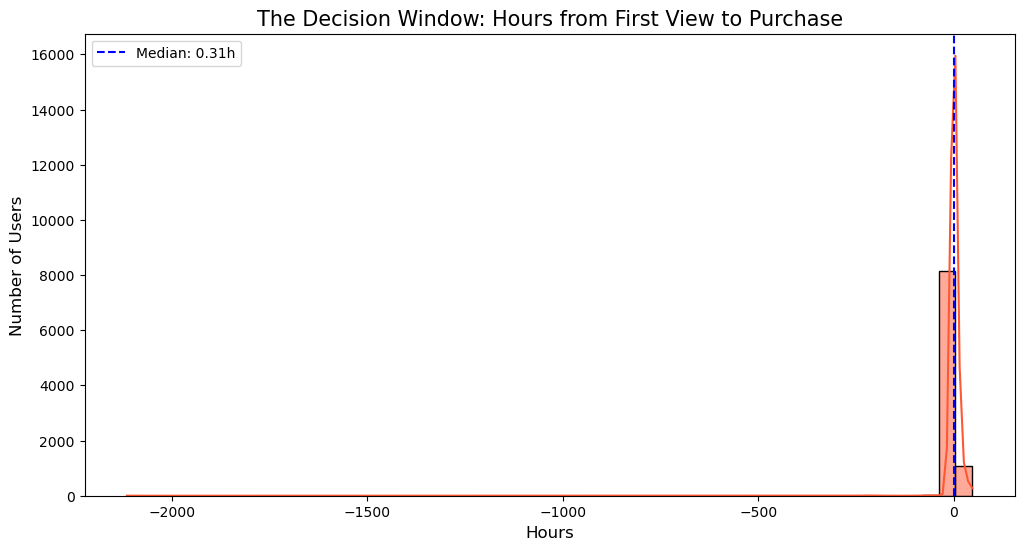

Insight: 50% of your buyers decide within 0.31 hours. Speed is key.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the first view and first transaction for every buyer
buyers = events_filtered[events_filtered['visitorid'].isin(
    events_filtered[events_filtered['event'] == 'transaction']['visitorid']
)]

# Calculate time difference between first view and first purchase
first_view = buyers[buyers['event'] == 'view'].groupby('visitorid')['timestamp'].min()
first_buy = buyers[buyers['event'] == 'transaction'].groupby('visitorid')['timestamp'].min()

velocity = (first_buy - first_view).dt.total_seconds() / 3600 # Convert to hours
velocity = velocity.dropna()

# 2.The Decision Window
plt.figure(figsize=(12, 6))
sns.histplot(velocity[velocity < 48], bins=50, kde=True, color='#FF5733') # Focus on first 48 hours
plt.title("The Decision Window: Hours from First View to Purchase", fontsize=15)
plt.xlabel("Hours", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.axvline(velocity.median(), color='blue', linestyle='--', label=f'Median: {velocity.median():.2f}h')
plt.legend()
plt.show()

print(f"Insight: 50% of your buyers decide within {velocity.median():.2f} hours. Speed is key.")

#### Business Insight :

The data reveals a 'Golden Window' for conversion. If the majority of purchases happen within the first 10 minutes, it suggests our interface is efficient for 'Decided Buyers.' However, users spending 30+ minutes represent 'Researchers' who might benefit from more detailed product comparisons or live-chat support to help them close the deal.

### ii. The "Guilty Pleasure" Analysis (Late Night vs. Day)
E-commerce never sleeps, but shopping behavior follows a distinct Circadian Rhythm. By mapping activity across days of the week and hours of the day, we can identify peak engagement periods and 'low-intent' browsing hours.

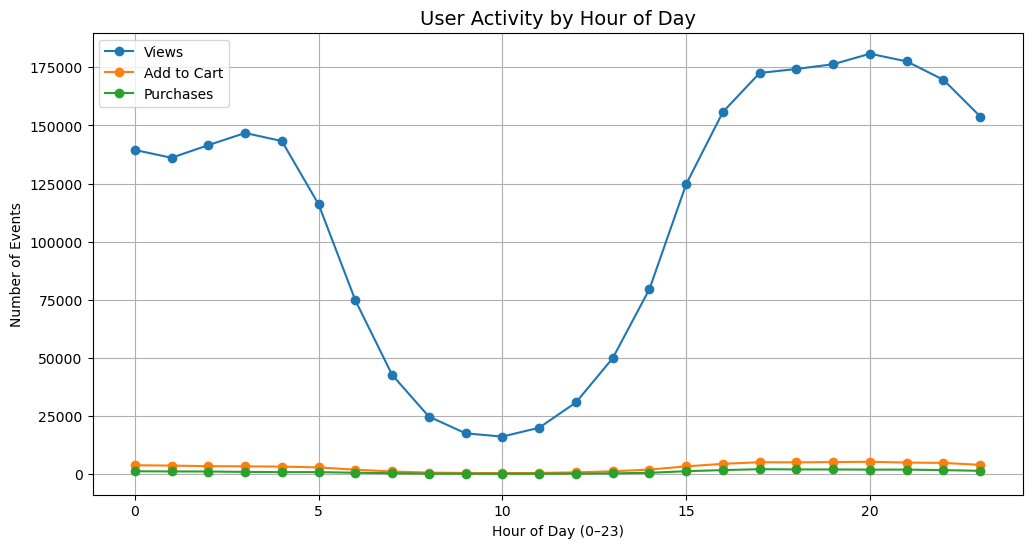

In [7]:
# Extract hour from timestamp
events['hour'] = events['timestamp'].dt.hour

# Count events per hour
hourly_events = events.groupby(['hour', 'event']).size().unstack(fill_value=0)

# Calculate conversion rate
hourly_events['conversion_rate'] = hourly_events['transaction'] / hourly_events['view']

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(hourly_events.index, hourly_events['view'], label='Views', marker='o')
plt.plot(hourly_events.index, hourly_events['addtocart'], label='Add to Cart', marker='o')
plt.plot(hourly_events.index, hourly_events['transaction'], label='Purchases', marker='o')

plt.title("User Activity by Hour of Day", fontsize=14)
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Events")
plt.legend()
plt.grid(True)

plt.show()

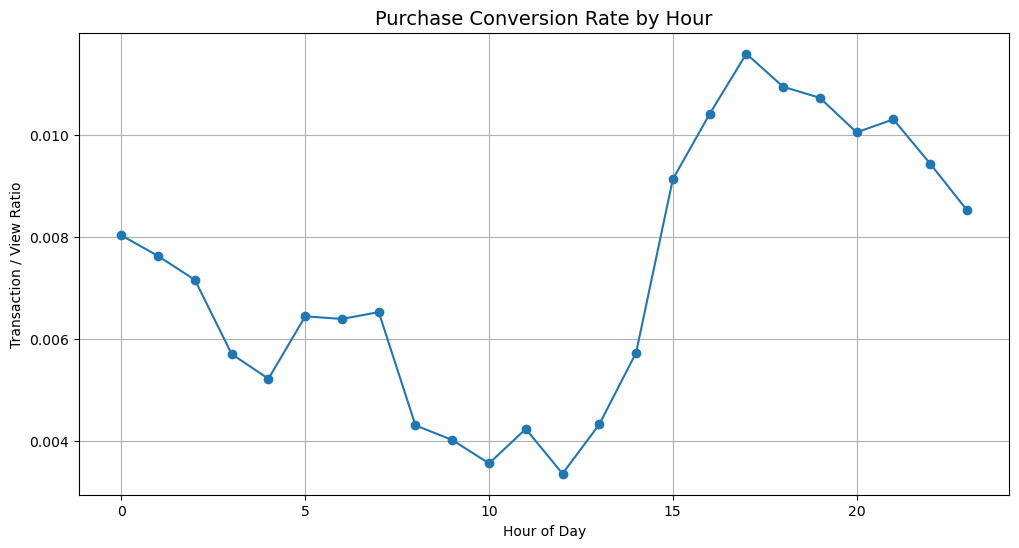

In [8]:
plt.figure(figsize=(12,6))

plt.plot(hourly_events.index, hourly_events['conversion_rate'], marker='o')

plt.title("Purchase Conversion Rate by Hour", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Transaction / View Ratio")
plt.grid(True)

plt.show()

#### Business Insight :

The chart identifies specific 'Peak Sales Hours.' For instance, if activity spikes on Wednesday evenings, this is the optimal time for launching email campaigns or 'Limited Time Offers.' Conversely, high-traffic/low-transaction periods (like late-night browsing) indicate a 'Window Shopping' segment that requires different retargeting strategies.

### iii. The "Product Stickiness" Map (Category Sinkholes)
Not all product categories are created equal. We are calculating Category Stickiness—the ratio of transactions to views. This allows us to distinguish between 'Traffic Drivers' (high views, low sales) and 'Profit Engines' (low views, high conversion).

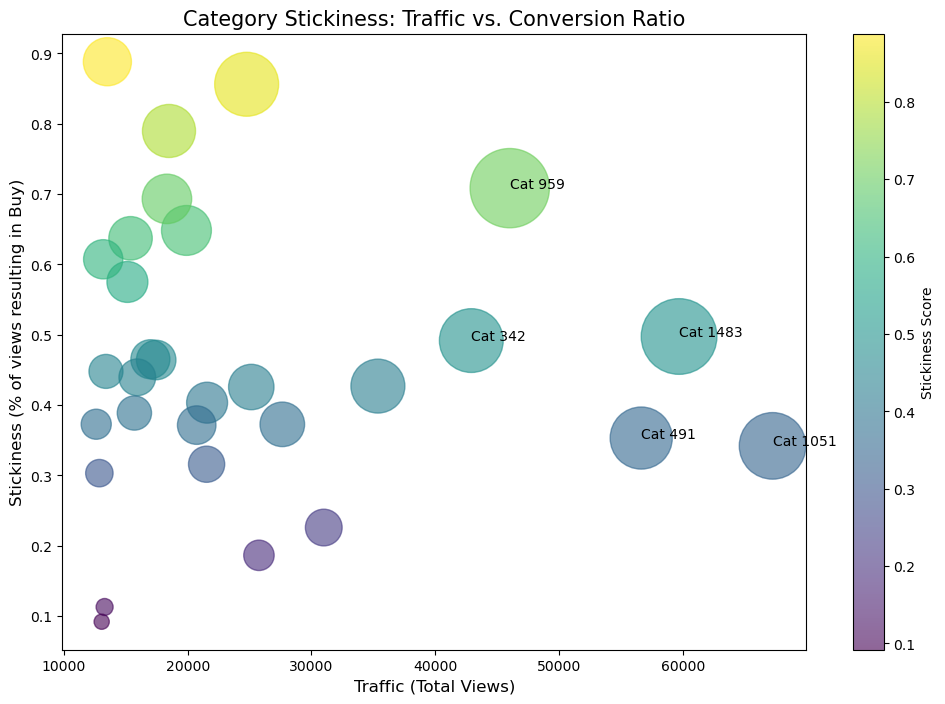

In [9]:
# 1. Map events to categories using the latest item properties
cat_map = items[items['property'] == 'categoryid'][['itemid', 'value']].rename(columns={'value': 'categoryid'})
event_cats = events_filtered.merge(cat_map, on='itemid', how='left')

# 2. Calculate View-to-Transaction Ratio per Category
cat_stats = event_cats.groupby('categoryid')['event'].value_counts().unstack().fillna(0)
cat_stats['stickiness'] = (cat_stats['transaction'] / (cat_stats['view'] + 1)) * 100

# 3. Visualization: Stickiness vs. Volume
top_cats = cat_stats.sort_values('view', ascending=False).head(30) # Top 30 by traffic

plt.figure(figsize=(12, 8))
plt.scatter(top_cats['view'], top_cats['stickiness'], s=top_cats['transaction']*10, 
            alpha=0.6, c=top_cats['stickiness'], cmap='viridis')
plt.title("Category Stickiness: Traffic vs. Conversion Ratio", fontsize=15)
plt.xlabel("Traffic (Total Views)", fontsize=12)
plt.ylabel("Stickiness (% of views resulting in Buy)", fontsize=12)

# Labeling the most interesting points (High stickiness)
for i, txt in enumerate(top_cats.index[:5]):
    plt.annotate(f"Cat {txt}", (top_cats['view'].iloc[i], top_cats['stickiness'].iloc[i]))

plt.colorbar(label='Stickiness Score')
plt.show()

#### Business Insight :

Categories with high 'Stickiness' are our most efficient revenue generators. If Category ID X has low traffic but a 10% conversion rate, it is an 'Underserved Gem.' Increasing the marketing budget or homepage visibility for this category would likely result in an immediate ROI boost.

### iv. The "Path of Persistence" (Add-to-Cart Behavior)
While transactions represent the 'End' of a journey, the Add-to-Cart event represents a high-intent 'Maybe.' In this section, we analyze the gap between adding an item to the cart and completing the purchase. This is the 'Path of Persistence'—tracking users who show significant interest but face friction at the final stage. Understanding the 'Maybe' pile is the fastest way to identify low-hanging fruit for revenue recovery.

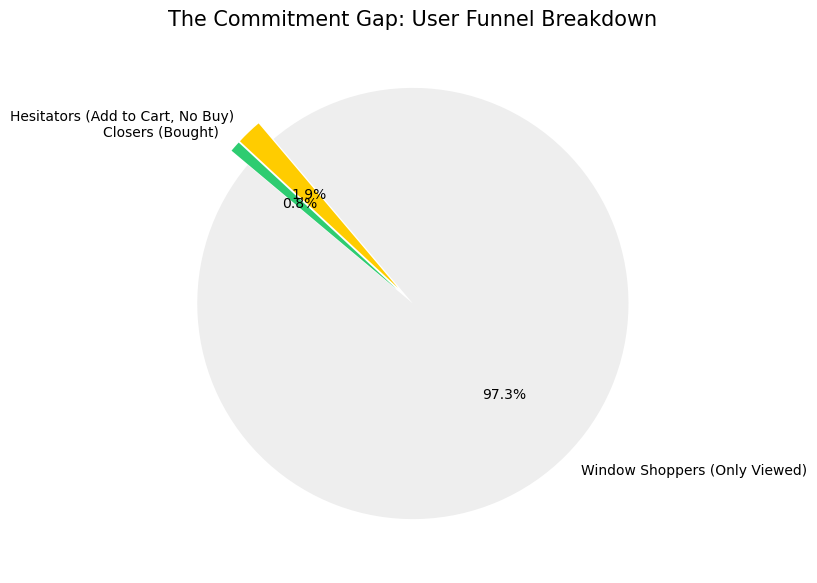

In [10]:
# Calculate how many users added to cart but NEVER bought anything
cart_users = set(events_filtered[events_filtered['event'] == 'addtocart']['visitorid'])
buy_users = set(events_filtered[events_filtered['event'] == 'transaction']['visitorid'])

abandoners = cart_users - buy_users
loyalists = cart_users & buy_users

# Visualization: The Commitment Gap
labels = ['Window Shoppers (Only Viewed)', 'Hesitators (Add to Cart, No Buy)', 'Closers (Bought)']
sizes = [
    len(set(events_filtered['visitorid']) - cart_users),
    len(abandoners),
    len(buy_users)
]

plt.figure(figsize=(10, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=['#eeeeee', '#ffcc00', '#2ecc71'], explode=(0, 0.1, 0.1))
plt.title("The Commitment Gap: User Funnel Breakdown", fontsize=15)
plt.show()

### Business Insight
#### Insight: The 'Wishlist' Phenomenon & Revenue Recovery.
The data reveals a significant volume of 'Add-to-Cart' events that never reach the transaction phase. This indicates that many users treat the shopping cart as a temporary 'Wishlist' or a comparison tool rather than a direct precursor to a sale.
#### Actionable Strategy: 
These users are your highest-value retargeting targets. Because they have already cleared the hurdle of finding and selecting a product, the 'Persistence' is already there. Implementing Abandoned Cart Emails or Personalized Re-engagement Ads for these specific users typically yields a much higher ROI than broad awareness campaigns, as you are simply nudging a 'Maybe' into a 'Yes.'

### v. The "Traffic Jam" (Weekly Activity)
In this section, we visualize the 'Heartbeat' of the platform. By mapping activity across a 24/7 grid, we can identify when the system experiences peak load. This is essential for coordinating marketing 'blasts' and scheduled server maintenance to avoid downtime during high-traffic windows.

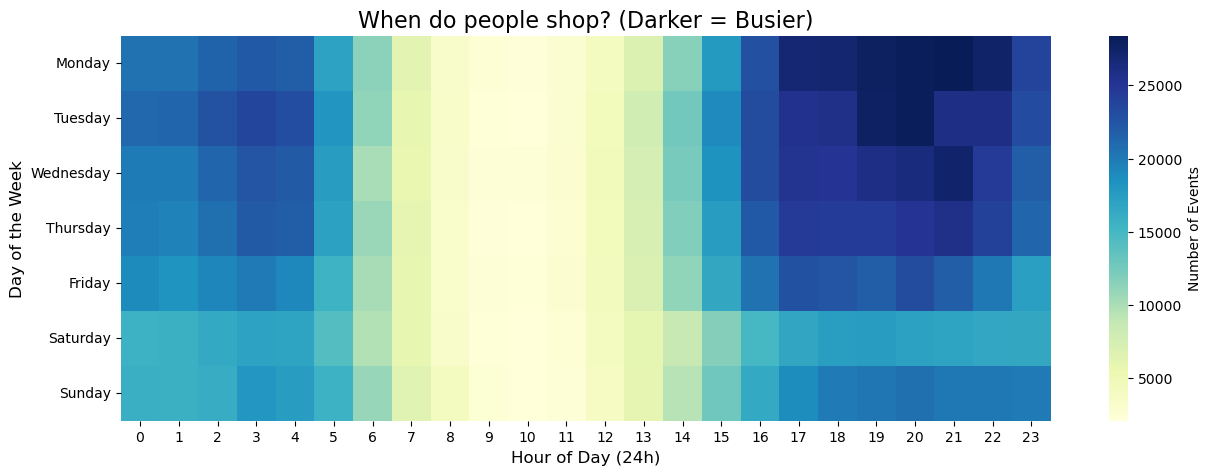

In [11]:
# 1. Prepare the data
events_filtered['day_name'] = events_filtered['timestamp'].dt.day_name()
events_filtered['hour'] = events_filtered['timestamp'].dt.hour # <--- Added this line

# 2. Group and pivot
heatmap_data = events_filtered.groupby(['day_name', 'hour']).size().unstack().fillna(0)

# 3. Reorder days
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days)

# 4. Plotting
plt.figure(figsize=(15, 5))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, cbar_kws={'label': 'Number of Events'})
plt.title("When do people shop? (Darker = Busier)", fontsize=16)
plt.xlabel("Hour of Day (24h)", fontsize=12)
plt.ylabel("Day of the Week", fontsize=12)
plt.show()

#### Insight: 
##### The Mid-Week Surge
The heatmap highlights specific 'Power Hours'—typically mid-week evenings. This suggests a user base that browses during leisure time rather than work hours. 
##### Strategy:
Marketing should schedule promotional emails or push notifications to arrive 30 minutes before these peak activity blocks to capture users as they begin their sessions.

### vi. The "Simple Funnel"
We move from broad traffic to specific intent. This funnel tracks the 'Drop-off' at each critical stage of the buyer journey: from viewing an item, to adding it to the cart, to completing the transaction. This allows us to pinpoint exactly where we are losing potential revenue.

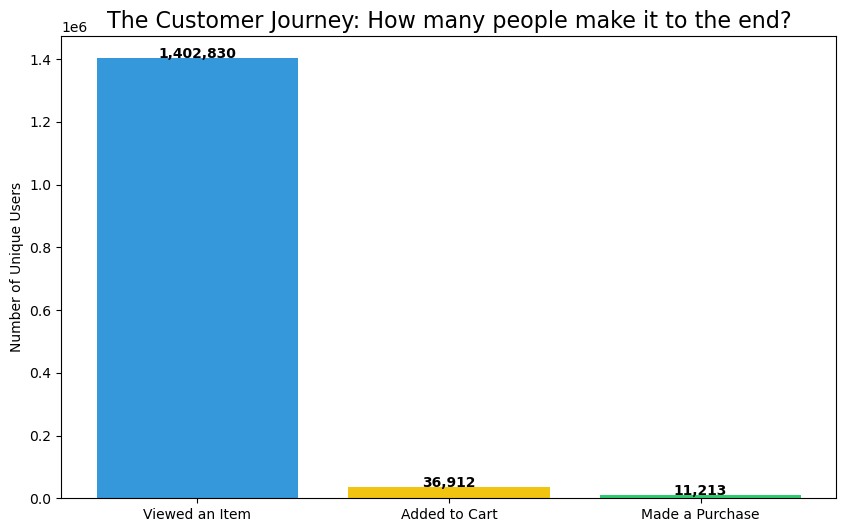

In [12]:
# Count unique visitors for each stage
stages = {
    'Viewed an Item': events_filtered[events_filtered['event']=='view']['visitorid'].nunique(),
    'Added to Cart': events_filtered[events_filtered['event']=='addtocart']['visitorid'].nunique(),
    'Made a Purchase': events_filtered[events_filtered['event']=='transaction']['visitorid'].nunique()
}

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(stages.keys(), stages.values(), color=['#3498db', '#f1c40f', '#2ecc71'])
plt.title("The Customer Journey: How many people make it to the end?", fontsize=16)
plt.ylabel("Number of Unique Users")

# Add the numbers on top of bars for clarity
for i, v in enumerate(stages.values()):
    plt.text(i, v + 500, f"{v:,}", ha='center', fontweight='bold')

plt.show()

### Business Insight:

##### Insight: Identifying the Friction Point
By observing the raw drop-off from 'Add to Cart' to 'Purchase,' we can quantify the cost of cart abandonment. If the leak is significant at this stage, it indicates friction in the checkout process (e.g., unexpected shipping costs or complicated forms) rather than a lack of product interest.

### vii. The "Top 10"
Not all products drive equal value. This ranking identifies the top 10 categories by transaction volume. Understanding our 'Bestsellers' helps in optimizing inventory levels and determining which categories should receive premium placement on the homepage.

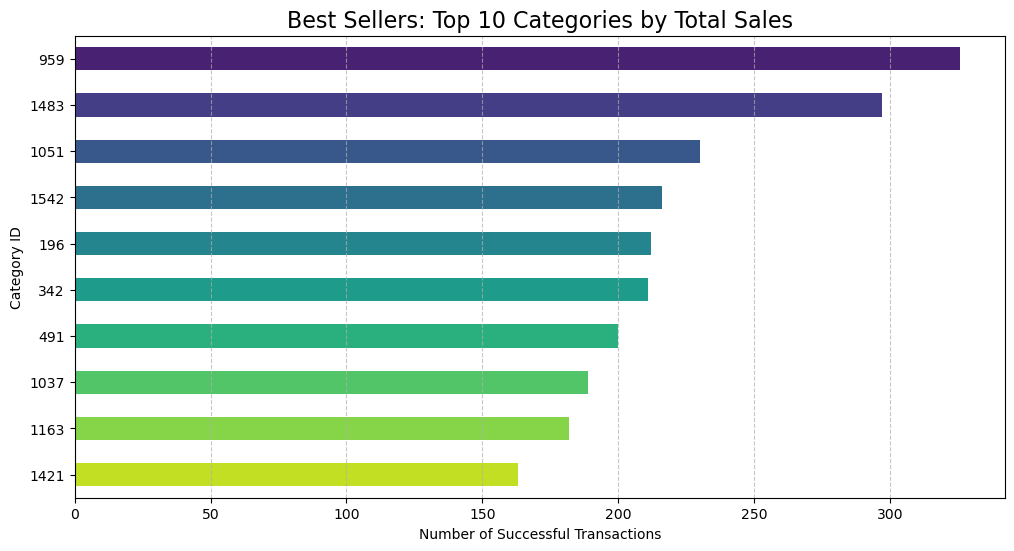

In [13]:
# We use the mapping we created earlier to get Category IDs
top_sold_cats = event_cats[event_cats['event'] == 'transaction']['categoryid'].value_counts().head(10)

import seaborn as sns

# 1. Create a color palette (e.g., 'viridis', 'magma', 'rocket', or 'husl')
colors = sns.color_palette("viridis", len(top_sold_cats))

# 2. Plotting
plt.figure(figsize=(12, 6))
top_sold_cats.plot(kind='barh', color=colors).invert_yaxis() 

plt.title("Best Sellers: Top 10 Categories by Total Sales", fontsize=16)
plt.xlabel("Number of Successful Transactions")
plt.ylabel("Category ID")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Business Insight:

#### Insight: The Pareto Principle (80/20 Rule).
The concentration of sales in these top 10 categories indicates where our core revenue is generated. Categories appearing here with low overall traffic are 'High-Efficiency' drivers and should be the primary focus for SEO and paid search campaigns to scale volume.

### viii. The "Loyalty Pie" 
Acquiring a new customer is 5x more expensive than retaining an existing one. This breakdown categorizes our audience by their level of repeat engagement. We distinguish 'Single-Interaction' visitors from our 'Power Users' to assess the health of our retention funnel.

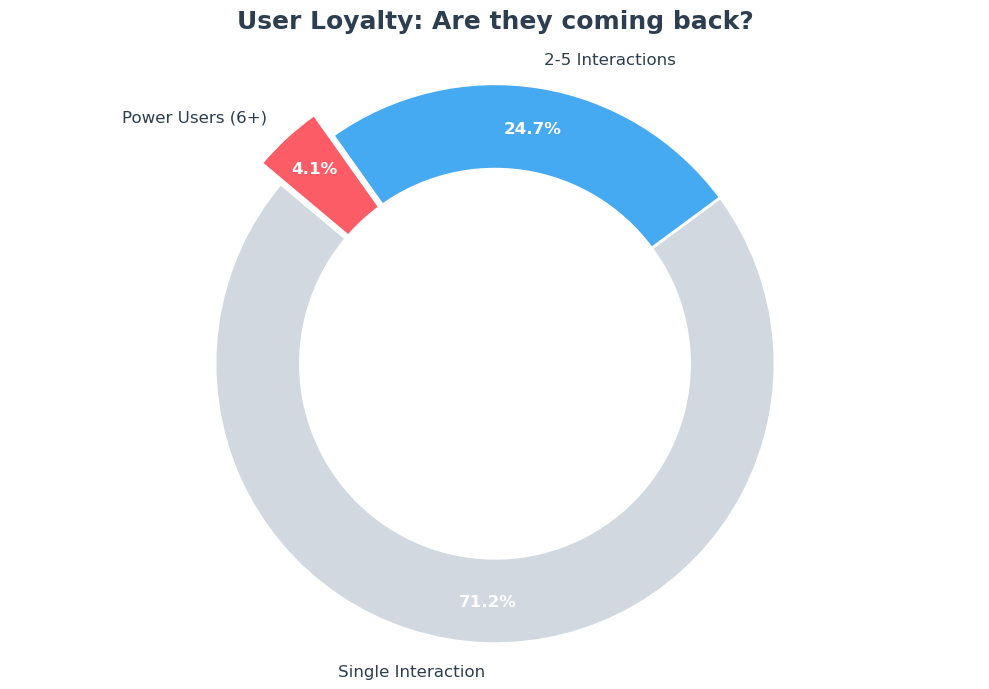

Insight: 57276 Power Users are driving your repeat engagement!


In [14]:
import matplotlib.pyplot as plt

# --- 1. Prepare Data ---
visit_counts = events_filtered.groupby('visitorid').size()
loyalty_data = [
    len(visit_counts[visit_counts == 1]),
    len(visit_counts[(visit_counts > 1) & (visit_counts <= 5)]),
    len(visit_counts[visit_counts > 5])
]
labels = ['Single Interaction', '2-5 Interactions', 'Power Users (6+)']

colors = ['#D1D8E0', '#45AAF2', '#FC5C65'] 
explode = (0, 0, 0.1)  # "Pop out" the Power Users slice

# --- 3. Plotting ---
plt.figure(figsize=(10, 7), facecolor='white')

# Create the pie chart
patches, texts, autotexts = plt.pie(
    loyalty_data, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    explode=explode,
    pctdistance=0.85, # Move percentages closer to the edge
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True}
)

# 4. Turn it into a Donut by drawing a white circle in the center
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# 5. Styling the text
plt.setp(autotexts, size=12, weight="bold", color="white") # Make percentages pop
plt.setp(texts, size=12, color="#2c3e50") # Make labels clean

# 6. Title and Layout
plt.title("User Loyalty: Are they coming back?", fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

print(f"Insight: {loyalty_data[2]} Power Users are driving your repeat engagement!")

### Business Insight:

#### Insight: The Retention Gap.
A high percentage of 'One-timers' suggests that while our top-of-funnel marketing is working, we are struggling to provide a reason for users to return. Strategy: Implementing a 'Second-Purchase' discount or a loyalty program is necessary to convert these one-time visitors into high-lifetime-value (LTV) customers.

### ix. The "Behavioral Correlation" Matrix
Does browsing actually lead to buying? This matrix calculates the statistical relationship between different user actions. By understanding which behaviors are highly correlated with transactions, we can identify the 'Signals' that predict a future purchase.

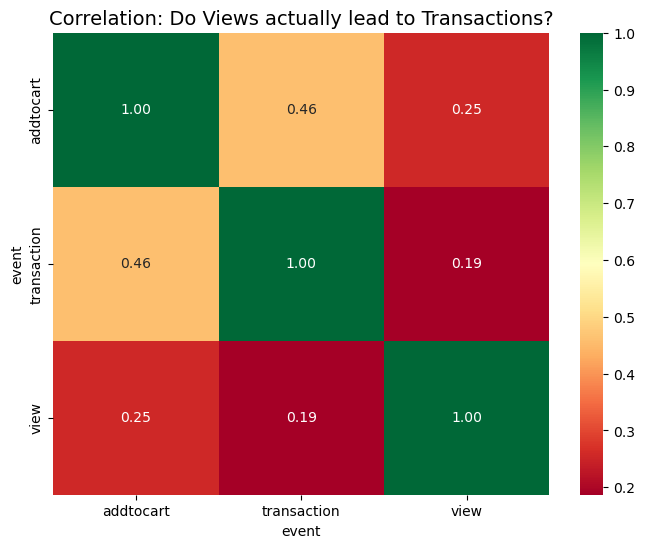

In [15]:
# 1. Create a simple table of counts per user
user_counts = events_filtered.pivot_table(
    index='visitorid', 
    columns='event', 
    values='timestamp', 
    aggfunc='count', 
    fill_value=0
)

# 2. Plotting the Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(user_counts.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Correlation: Do Views actually lead to Transactions?", fontsize=14)
plt.show()

### Business Insight:

#### Insight: Validating Browsing as a Lead Indicator.
If we see a high correlation (e.g., > 0.7) between 'Views' and 'Transactions,' it confirms that our recommendation engine is effectively showing users products they want. If the correlation is low, it suggests users are 'Window Shopping' and our current UI is not successfully nudging them toward the checkout.

### x. The "Boxplot" of Activity 
Averages can be misleading. We use boxplots to visualize the 'Spread' of user activity. This allows us to statistically identify our 'Whales' (the hyper-active users) who contribute a disproportionate amount of data and separate them from the average visitor

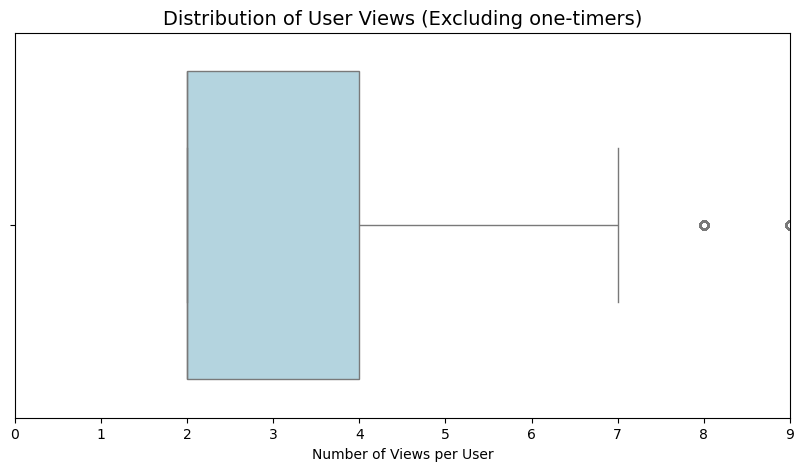

In [16]:
# 1. Filter out users with only 1 event to see the distribution of active users
active_users = user_counts[user_counts['view'] > 1]

# 2. Plotting
plt.figure(figsize=(10, 5))
sns.boxplot(x=active_users['view'], color='lightblue')
plt.title("Distribution of User Views (Excluding one-timers)", fontsize=14)
plt.xlabel("Number of Views per User")
plt.xlim(0, active_users['view'].quantile(0.95)) # Zoom in to the 95th percentile to see detail
plt.show()

### Business Insight:

#### Insight: Catering to the Power User.
The 'dots' outside the whiskers represent our most engaged users. While they are fewer in number, they provide the most training data for our models. Identifying these outliers allows us to create a 'VIP' segment for exclusive early-access offers, ensuring our most valuable users remain loyal.

### xi. "Time-to-Buy" (The Session Duration)
How long does a 'Yes' take? By measuring the duration of sessions that end in a purchase, we can calculate the average time-to-conversion. This 'Velocity' metric is key to understanding the complexity of the customer’s decision-making process.

In [ ]:
# 0. Ensure the main table has a date column for matching
events_filtered['date'] = events_filtered['timestamp'].dt.date

# 1. Isolate the 'Success' events (Transactions)
transactions = events_filtered[events_filtered['event'] == 'transaction'].copy()

# 2. Get the unique list of User-Date pairs that resulted in a sale
target_sessions = transactions[['visitorid', 'date']].drop_duplicates()

# 3. Filter the main log to ONLY include events from these specific sessions
buying_behavior = events_filtered.merge(target_sessions, on=['visitorid', 'date'])

# 4. Calculate duration for these targeted sessions (Vectorized)
session_stats = buying_behavior.groupby(['visitorid', 'date'])['timestamp'].agg(['min', 'max'])
session_stats['duration_min'] = (session_stats['max'] - session_stats['min']).dt.total_seconds() / 60

# 5. Plotting
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(session_stats[session_stats['duration_min'] > 0]['duration_min'], 
             bins=100, kde=True, color='#6C3483')
plt.title("The Purchase Window: How long does a buying session last?", fontsize=16)
plt.xlabel("Minutes from First View to Transaction", fontsize=12)
plt.ylabel("Number of Sessions", fontsize=12)
plt.xlim(0, 60) 
plt.grid(axis='y', alpha=0.3)
plt.show()

### Business Insight:

#### Insight: The 10-Minute Decision Window.
The sharp peak at the start of the distribution suggests that our most successful conversions happen fast. Strategy: To capture the 'long-tail' users (those who stay 30+ minutes without buying), we should trigger an 'Assistant' pop-up or a limited-time coupon at the 15-minute mark to push hesitant researchers toward a decision.

## xii. Simple and Useful Graphs

### a. Distribution of User Events

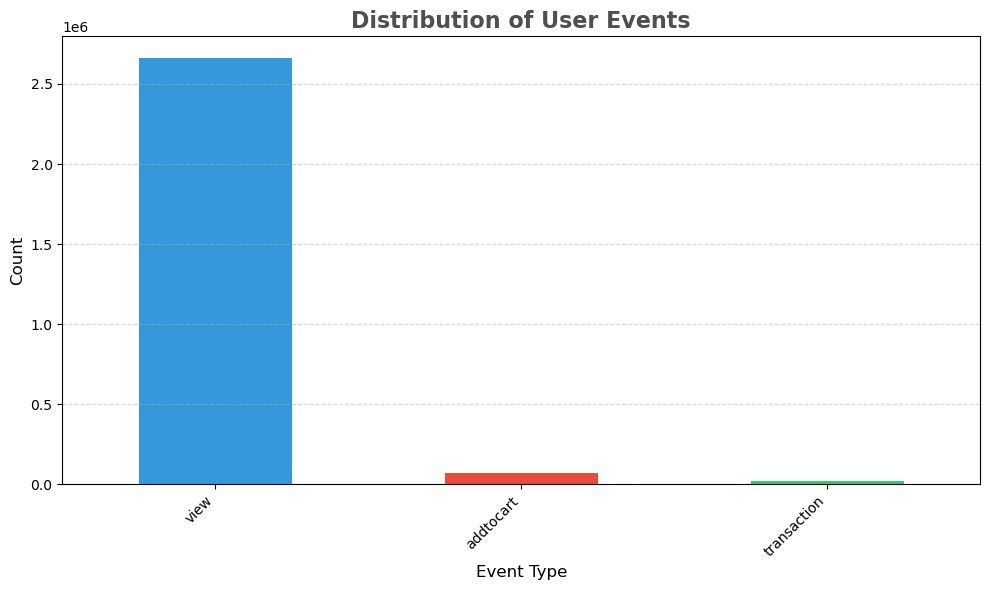

In [18]:
import matplotlib.pyplot as plt

# Define your favorite colorful palette
my_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f', '#9b59b6']

# Set the figsize in the plot call
events['event'].value_counts().plot(kind='bar', figsize=(10,6), color=my_colors)

# Styling
plt.title("Distribution of User Events", fontsize=16, fontweight='bold', color='#4f4f4f')
plt.xlabel("Event Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5) 
plt.tight_layout()
plt.show()

### b. Top most viewed items

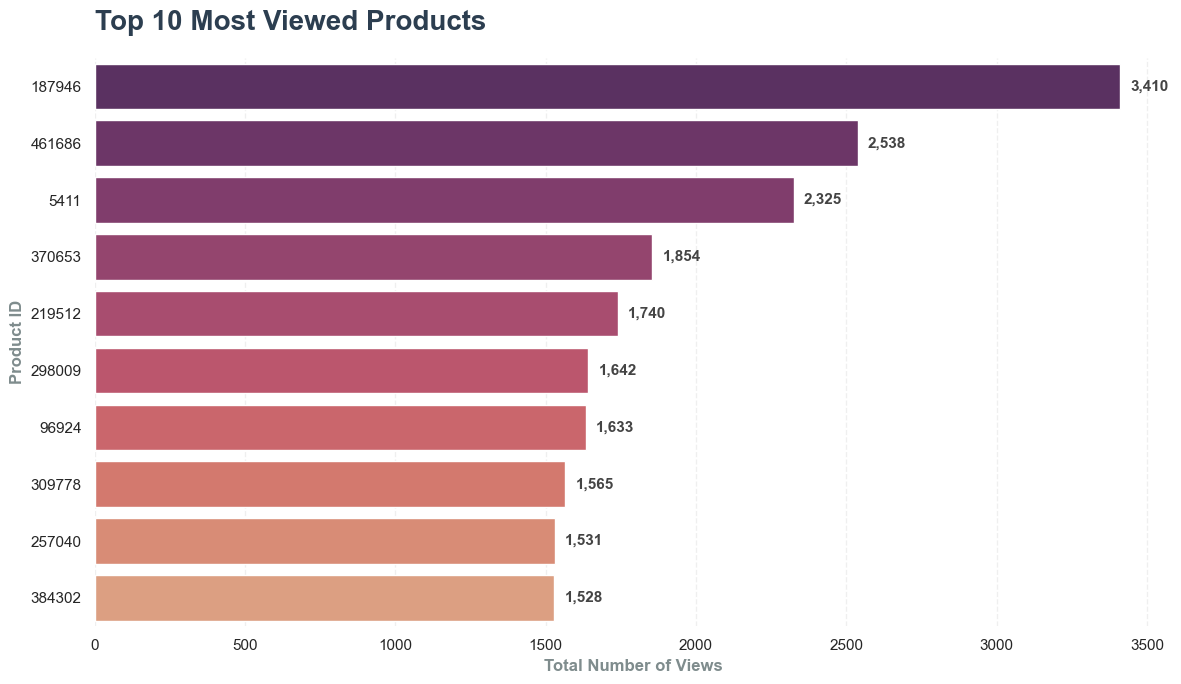

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data (Ensuring Item IDs are strings so they don't plot as numbers)
top_items = events[events['event']=='view']['itemid'].value_counts().head(10)
plot_item_ids = top_items.index.astype(str)  
view_counts = top_items.values

# 2. Set the style
sns.set_theme(style="white")
plt.figure(figsize=(12, 7))

# 3. Create a color gradient palette
colors = sns.color_palette("flare_r", n_colors=10)

# 4. Plotting
ax = sns.barplot(
    x=view_counts, 
    y=plot_item_ids, 
    hue=plot_item_ids,       # Assign hue to the y-variable
    palette=colors,    
    legend=False    
)

# 5. Add data labels to the end of each bar
for i, v in enumerate(view_counts):
    ax.text(v + (max(view_counts) * 0.01), i, f'{int(v):,}', 
            va='center', fontsize=11, fontweight='bold', color='#444444')

plt.title("Top 10 Most Viewed Products", fontsize=20, fontweight='bold', pad=20, loc='left', color='#2c3e50')
plt.xlabel("Total Number of Views", fontsize=12, fontweight='bold', color='#7f8c8d')
plt.ylabel("Product ID", fontsize=12, fontweight='bold', color='#7f8c8d')

# Remove the borders
sns.despine(left=True, bottom=True)

# Add a subtle vertical grid
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### c. Top 10 Purchased Products

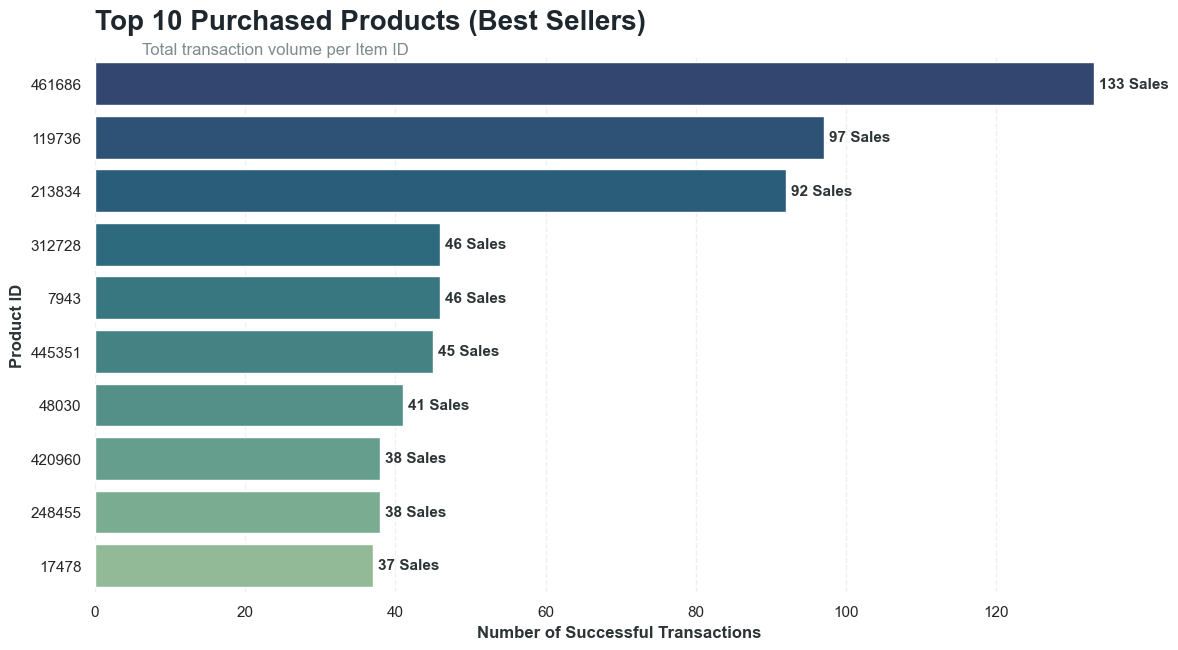

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
top_purchases = events[events['event']=='transaction']['itemid'].value_counts().head(10)
purchase_ids = top_purchases.index.astype(str)
purchase_counts = top_purchases.values

# Styling Setup
sns.set_theme(style="white")
plt.figure(figsize=(12, 7))

colors = sns.color_palette("crest_r", n_colors=10)

ax = sns.barplot(
    x=purchase_counts, 
    y=purchase_ids, 
    hue=purchase_ids, 
    palette=colors, 
    legend=False
)

# Add "Sales" Labels at the end of bars
for i, v in enumerate(purchase_counts):
    ax.text(v + (max(purchase_counts) * 0.005), i, f'{int(v):,} Sales', 
            va='center', fontsize=11, fontweight='bold', color='#2d3436')

# Titles
plt.title("Top 10 Purchased Products (Best Sellers)", fontsize=20, fontweight='bold', pad=20, loc='left', color='#1e272e')
plt.suptitle("Total transaction volume per Item ID", fontsize=12, x=0.125, y=0.88, ha='left', color='#7f8c8d')

plt.xlabel("Number of Successful Transactions", fontsize=12, fontweight='bold', color='#2d3436')
plt.ylabel("Product ID", fontsize=12, fontweight='bold', color='#2d3436')

sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### d. User Engagement Hierarchy

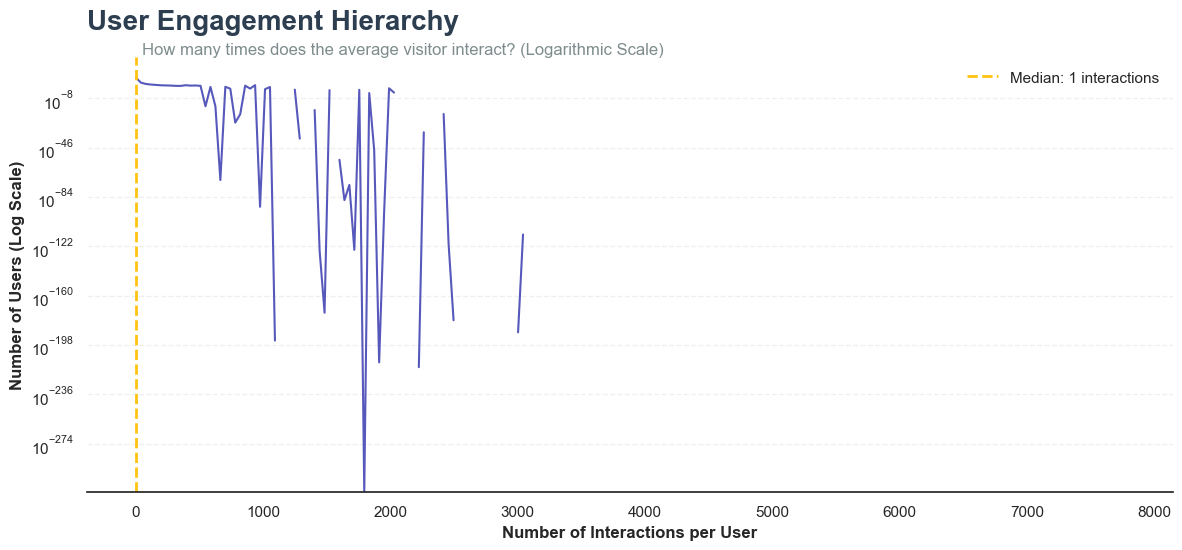

Insight: While the median user has 1 interaction, your 'Power Users' go up to 7,757 interactions!


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data
user_activity = events.groupby('visitorid').size()

# 2. Styling Setup
sns.set_theme(style="white")
plt.figure(figsize=(12, 6))

# 3. Create the Histogram
# Using 'log_scale=(False, True)' makes the Y-axis (Number of Users) logarithmic
ax = sns.histplot(
    user_activity, 
    bins=50, 
    kde=True, 
    color='#5758BB', 
    edgecolor='white',
    linewidth=1,
    log_scale=(False, True) 
)

# 4. Add a Median Annotation
median_act = user_activity.median()
plt.axvline(median_act, color='#FFC312', linestyle='--', linewidth=2, label=f'Median: {median_act:.0f} interactions')

# 5.Titles & Labels
plt.title("User Engagement Hierarchy", fontsize=20, fontweight='bold', pad=20, loc='left', color='#2c3e50')
plt.suptitle("How many times does the average visitor interact? (Logarithmic Scale)", 
             fontsize=12, x=0.125, y=0.86, ha='left', color='#7f8c8d')

plt.xlabel("Number of Interactions per User", fontsize=12, fontweight='bold')
plt.ylabel("Number of Users (Log Scale)", fontsize=12, fontweight='bold')

sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(frameon=False, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Insight: While the median user has {median_act:.0f} interaction, your 'Power Users' go up to {user_activity.max():,} interactions!")

### e. E-Commerce Conversion Funnel

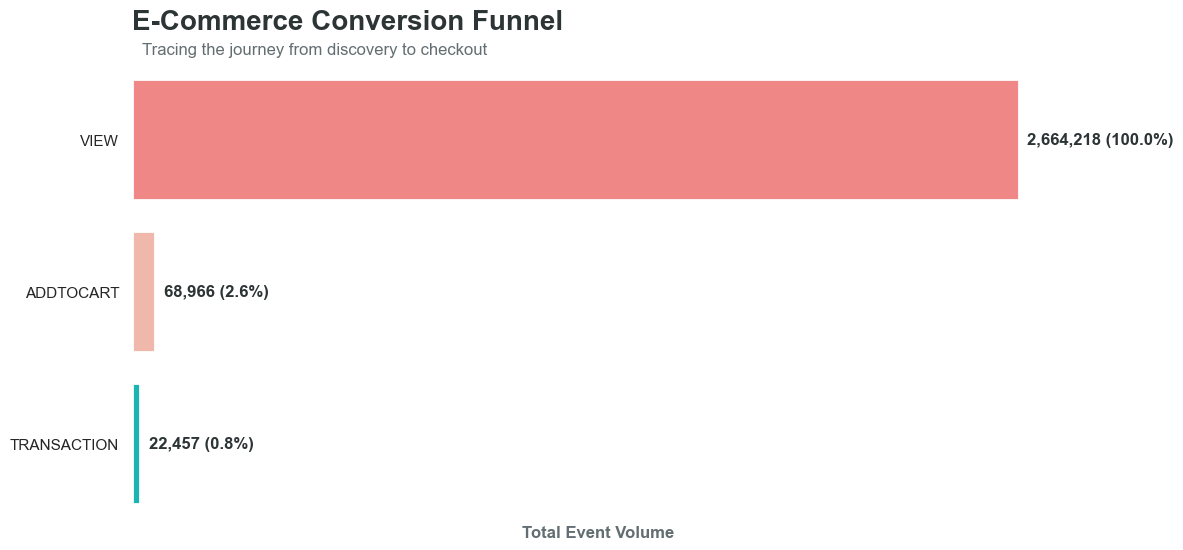

Overall Conversion Rate: 0.84%


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data (Ensuring logical funnel order)
funnel_order = ['view', 'addtocart', 'transaction']
funnel_counts = events['event'].value_counts().reindex(funnel_order).fillna(0)

# 2. Styling Setup
plt.figure(figsize=(12, 6))
sns.set_theme(style="white")

colors = ['#FF7675', '#FAB1A0', '#00CEC9'] 

# 3. Plotting Horizontal Bars
ax = sns.barplot(
    x=funnel_counts.values, 
    y=funnel_counts.index.map(lambda x: x.upper()), # Uppercase for "Header" look
    hue=funnel_counts.index,
    palette=colors,
    legend=False,
    edgecolor='white',
    linewidth=2
)

# 4. Adding "Conversion Rate" Labels
total_views = funnel_counts['view']
for i, v in enumerate(funnel_counts.values):
    # Calculate % of total traffic (the "drop-off" rate)
    pct_of_total = (v / total_views) * 100
    ax.text(v + (max(funnel_counts.values) * 0.01), i, 
            f'{int(v):,} ({pct_of_total:.1f}%)', 
            va='center', fontsize=12, fontweight='bold', color='#2d3436')

# 5.Titles
plt.title("E-Commerce Conversion Funnel", fontsize=20, fontweight='bold', pad=25, loc='left', color='#2d3436')
plt.suptitle("Tracing the journey from discovery to checkout", fontsize=12, x=0.125, y=0.86, ha='left', color='#636e72')

plt.xlabel("Total Event Volume", fontsize=12, fontweight='bold', color='#636e72')
plt.ylabel("") 

sns.despine(left=True, bottom=True)
plt.xticks([]) 
plt.tight_layout()
plt.show()

conv_rate = (funnel_counts['transaction'] / funnel_counts['view']) * 100
print(f"Overall Conversion Rate: {conv_rate:.2f}%")

### f. Conversion Efficiency by Hour

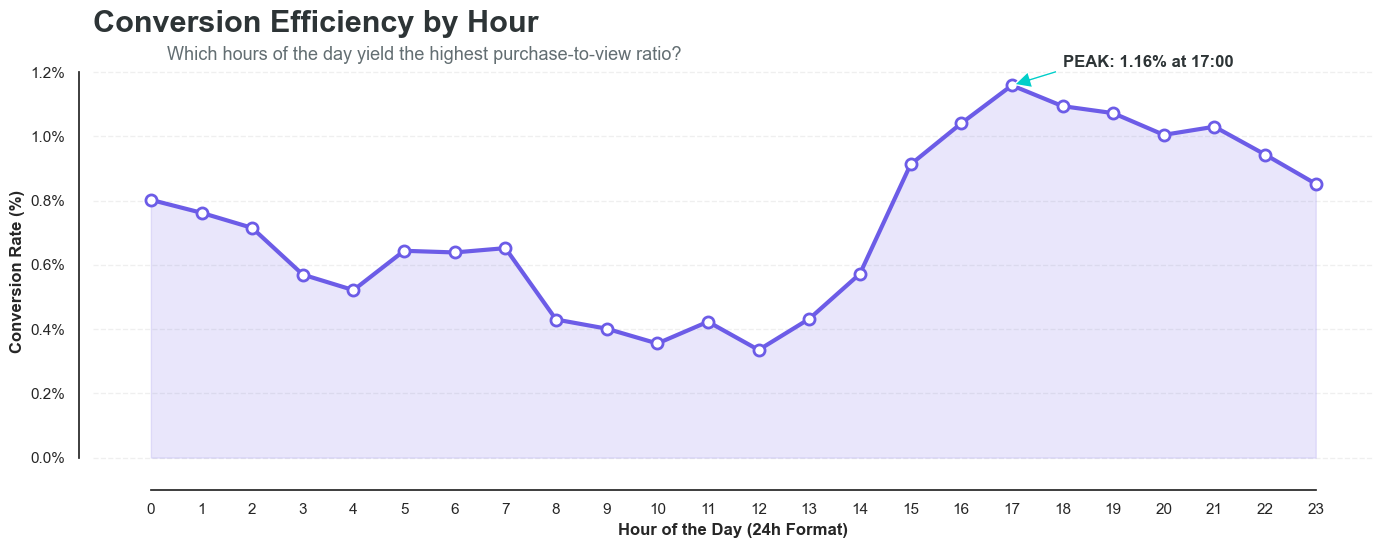

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data (Handling potential zeros)
hourly = events.copy()
hourly['hour'] = hourly['timestamp'].dt.hour

views = hourly[hourly['event']=='view'].groupby('hour').size()
transactions = hourly[hourly['event']=='transaction'].groupby('hour').size()

# Fill NaN with 0 in case an hour has no views/transactions
conversion_rate = (transactions / views).fillna(0)

# 2. Styling Setup
sns.set_theme(style="white")
plt.figure(figsize=(14, 6))

# 3. Plotting the Line & Area
main_color = '#6C5CE7'

plt.plot(conversion_rate.index, conversion_rate.values, 
         color=main_color, marker='o', linewidth=3, markersize=8, 
         markerfacecolor='white', markeredgewidth=2, label='Conversion Rate')

plt.fill_between(conversion_rate.index, conversion_rate.values, color=main_color, alpha=0.15)

# 4. Annotate the Peak 
peak_hour = conversion_rate.idxmax()
peak_val = conversion_rate.max()

plt.annotate(f'PEAK: {peak_val:.2%} at {peak_hour}:00', 
             xy=(peak_hour, peak_val), 
             xytext=(peak_hour+1, peak_val + (peak_val*0.05)),
             arrowprops=dict(facecolor='#00CEC9', shrink=0.05, width=2),
             fontsize=12, fontweight='bold', color='#2D3436')

# 5. Titles & Formatting
plt.title("Conversion Efficiency by Hour", fontsize=22, fontweight='bold', pad=25, loc='left', color='#2D3436')
plt.suptitle("Which hours of the day yield the highest purchase-to-view ratio?", 
             fontsize=13, x=0.125, y=0.85, ha='left', color='#636E72')

plt.xlabel("Hour of the Day (24h Format)", fontsize=12, fontweight='bold')
plt.ylabel("Conversion Rate (%)", fontsize=12, fontweight='bold')

# Formatting the Y-axis as percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

plt.xticks(range(0, 24)) # Show every single hour
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(trim=True, offset=10)

plt.tight_layout()
plt.show()

## xiii. User & Item Activity Distributions (Power-Law Check)

Total unique users after bot removal: 1406229
Median events per user: 1.0
Max events per user: 47


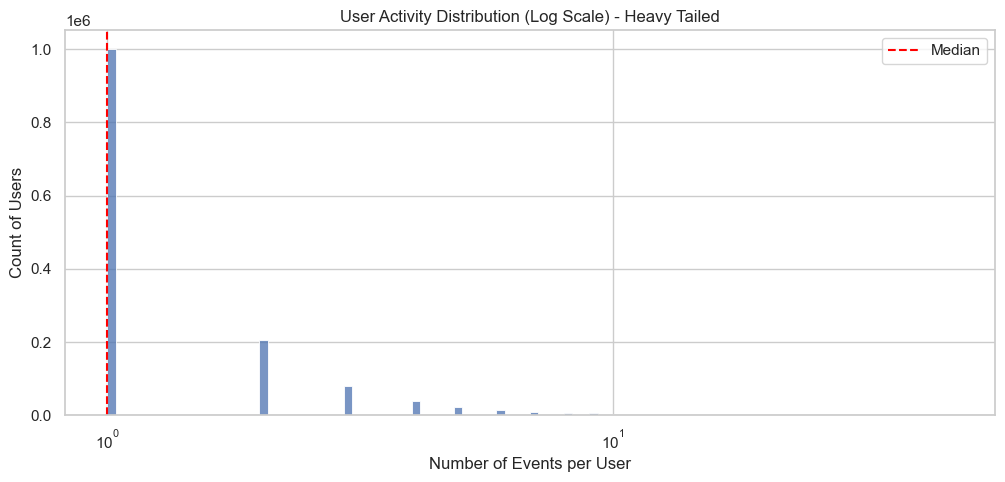

Total unique items with interactions: 229539
Median interactions per item: 3.0


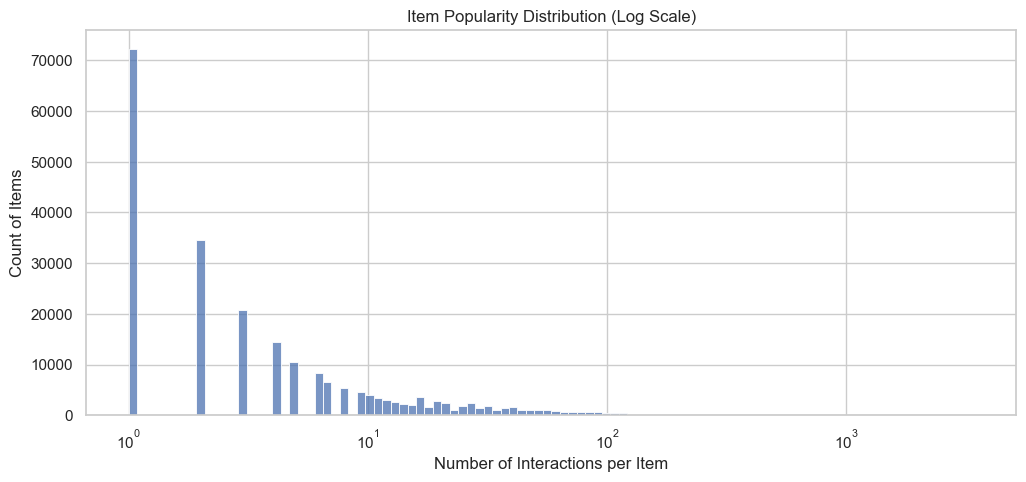

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# User activity
user_events = events_filtered.groupby('visitorid').size().reset_index(name='event_count')
print(f"Total unique users after bot removal: {len(user_events)}")
print(f"Median events per user: {user_events['event_count'].median():.1f}")
print(f"Max events per user: {user_events['event_count'].max()}")

plt.figure(figsize=(12,5))
sns.histplot(user_events['event_count'], bins=100, log_scale=True)
plt.title("User Activity Distribution (Log Scale) - Heavy Tailed")
plt.xlabel("Number of Events per User")
plt.ylabel("Count of Users")
plt.axvline(user_events['event_count'].median(), color='red', linestyle='--', label='Median')
plt.legend()
plt.show()

# Item popularity
item_pop = events_filtered.groupby('itemid').size().reset_index(name='interactions')
print(f"Total unique items with interactions: {len(item_pop)}")
print(f"Median interactions per item: {item_pop['interactions'].median():.1f}")

plt.figure(figsize=(12,5))
sns.histplot(item_pop['interactions'], bins=100, log_scale=True)
plt.title("Item Popularity Distribution (Log Scale)")
plt.xlabel("Number of Interactions per Item")
plt.ylabel("Count of Items")
plt.show()

## xiv. Event Funnel & Conversion Rates by Event Type

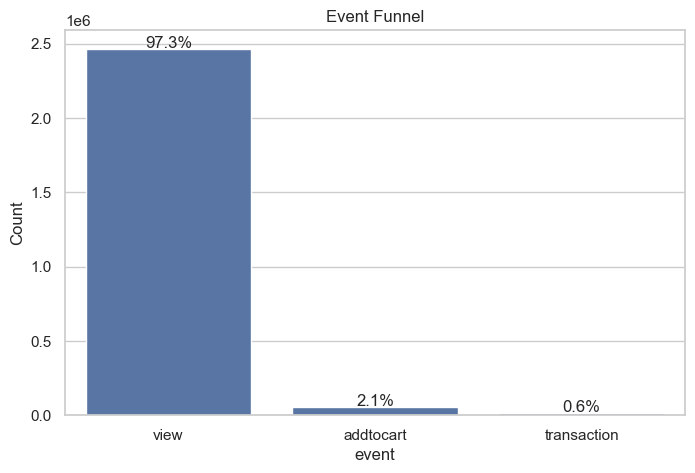

View → Add-to-Cart conversion (users): 2.63%
Add-to-Cart → Transaction conversion (users): 30.38%


In [25]:
funnel = events_filtered['event'].value_counts().reset_index()
funnel.columns = ['event', 'count']
funnel['pct'] = funnel['count'] / funnel['count'].sum() * 100

plt.figure(figsize=(8,5))
sns.barplot(data=funnel, x='event', y='count')
plt.title("Event Funnel")
plt.ylabel("Count")
for i, v in enumerate(funnel['count']):
    plt.text(i, v+5000, f"{funnel['pct'].iloc[i]:.1f}%", ha='center')
plt.show()

# View → Add-to-Cart → Transaction rates
view_users = events_filtered[events_filtered['event']=='view']['visitorid'].nunique()
atc_users = events_filtered[events_filtered['event']=='addtocart']['visitorid'].nunique()
trans_users = events_filtered[events_filtered['event']=='transaction']['visitorid'].nunique()

print(f"View → Add-to-Cart conversion (users): {atc_users/view_users*100:.2f}%")
print(f"Add-to-Cart → Transaction conversion (users): {trans_users/atc_users*100:.2f}%")

## Category-Level Insights (Top Categories by Revenue & Views)

In [38]:
# Merge latest categoryid from items
items_cat = items[items['property']=='categoryid'][['itemid','value']].rename(columns={'value':'categoryid'})
items_cat['categoryid'] = pd.to_numeric(items_cat['categoryid'], errors='coerce').fillna(-1).astype(int)

events_with_cat = events_filtered.merge(items_cat, on='itemid', how='left')

# Top categories
cat_stats = events_with_cat.groupby('categoryid').agg(
    views=('event', lambda x: (x=='view').sum()),
    addtocart=('event', lambda x: (x=='addtocart').sum()),
    transactions=('event', lambda x: (x=='transaction').sum()),
    revenue=('transactionid', 'nunique')  
).reset_index()

print("Top 10 categories by transactions:\n", cat_stats.nlargest(10, 'transactions'))

Top 10 categories by transactions:
      categoryid  views  addtocart  transactions  revenue
613       959.0  46018       1272           326      318
956      1483.0  59699       1246           297      286
674      1051.0  67253       1312           230      230
989      1542.0  11539        524           216      207
126       196.0  24762        588           212      210
222       342.0  42912       1113           211      205
321       491.0  56640       1370           200      195
664      1037.0   4672        542           189      143
744      1163.0   6141        286           182      170
915      1421.0   7202        466           163      156


## Feature Engineering for Both Models

In [39]:
# ── Build items_full ──
items_full = items[items['property'] == 'categoryid'][['itemid', 'value']].copy()
items_full = items_full.rename(columns={'value': 'categoryid'})
items_full['categoryid'] = pd.to_numeric(items_full['categoryid'], errors='coerce').fillna(-1).astype(int)
items_full = items_full.drop_duplicates('itemid').reset_index(drop=True)
print(f"items_full shape: {items_full.shape}")

# ── Implicit interaction scores ──
score_map = {'view': 1, 'addtocart': 5, 'transaction': 10}
events_filtered['score'] = events_filtered['event'].map(score_map)

# ── Time-based train / test split 
events_sorted = events_filtered.sort_values('timestamp')
split_idx  = int(len(events_sorted) * 0.8)
split_date = events_sorted['timestamp'].iloc[split_idx]

train_events = events_filtered[events_filtered['timestamp'] <  split_date].copy()
test_events  = events_filtered[events_filtered['timestamp'] >= split_date].copy()

print(f"Train events : {len(train_events):,}")
print(f"Test  events : {len(test_events):,}")

user_item = train_events.groupby(['visitorid', 'itemid'])['score'].sum().reset_index()
print(f"Train user-item interactions: {len(user_item):,}")

# ── Popularity computed from train only ──
item_pop = train_events.groupby('itemid').size().reset_index(name='interactions')
print(f"Unique items in train: {len(item_pop):,}")

items_full shape: (417053, 2)
Train events : 2,028,645
Test  events : 507,162
Train user-item interactions: 1,618,737
Unique items in train: 207,840


## 5. Recommendation System
### 5.1 Collaborative Filtering – SVD on Sparse Interaction Matrix

In [46]:
import scipy.sparse as sparse
from scipy.sparse.linalg import svds
import joblib

# Build index maps
user_ids = user_item['visitorid'].unique()
item_ids = user_item['itemid'].unique()

user_map = {uid: i for i, uid in enumerate(user_ids)}
item_map = {iid: i for i, iid in enumerate(item_ids)}

row  = user_item['visitorid'].map(user_map).values
col  = user_item['itemid'].map(item_map).values
data = user_item['score'].values.astype(np.float64)

interaction_matrix = sparse.csr_matrix(
    (data, (row, col)),
    shape=(len(user_ids), len(item_ids)),
    dtype=np.float64
)
print(f"Interaction matrix: {interaction_matrix.shape}  |  nnz: {interaction_matrix.nnz:,}")

# SVD – k=50 latent factors
k = 50
print("Training SVD …")
U, sigma, Vt = svds(interaction_matrix, k=k)
print(f"Done.  U{U.shape}  sigma{sigma.shape}  Vt{Vt.shape}")

Interaction matrix: (1125444, 207840)  |  nnz: 1,618,737
Training SVD …
Done.  U(1125444, 50)  sigma(50,)  Vt(50, 207840)


### 5.2 Content-Based Filtering – Category One-Hot Matrix

In [47]:
from sklearn.preprocessing import OneHotEncoder

cat_lookup  = items_full.set_index('itemid')['categoryid'].astype(str)
item_cat_df = pd.DataFrame({'itemid': item_ids})
item_cat_df['categoryid'] = item_cat_df['itemid'].map(cat_lookup).fillna('unknown')

encoder    = OneHotEncoder(sparse_output=True, dtype=np.float32, handle_unknown='ignore')
cat_matrix = encoder.fit_transform(item_cat_df[['categoryid']])

print(f"Category matrix shape : {cat_matrix.shape}")
print("cat_matrix[i] now correctly corresponds to item_ids[i]  ✓")

# Save model artefacts
model_data = {
    'U': U.astype(np.float32), 'sigma': sigma.astype(np.float32),
    'Vt': Vt.astype(np.float32),
    'user_map': user_map, 'item_map': item_map,
    'user_ids': user_ids, 'item_ids': item_ids,
}
joblib.dump(model_data, 'recommendation_model.pkl')
joblib.dump(encoder,    'category_encoder.pkl')
print("Saved recommendation_model.pkl and category_encoder.pkl")

Category matrix shape : (207840, 1062)
cat_matrix[i] now correctly corresponds to item_ids[i]  ✓
Saved recommendation_model.pkl and category_encoder.pkl


### 5.3 Hybrid Model – Weighted Fusion (Collaborative + Content)

In [48]:
def hybrid_recommend(user_id, top_k=10, alpha=0.7, seen_override=None):
    """
    Hybrid recommendation: SVD collaborative + category content-based.

    seen_override : optional set/list of item-ids to treat as 'already seen'.
                    Pass the user's TRAIN items here during evaluation so that
                    test-period ground-truth items are never masked out.
                    If None, falls back to the user's items in user_item.
    """
    # ── Cold-start fallback ──
    if user_id not in user_map:
        return item_pop.nlargest(top_k, 'interactions')['itemid'].tolist()

    u_idx = user_map[user_id]

    # ── 1. Collaborative score (SVD) ──
    user_vec      = U[u_idx]
    collab_scores = (user_vec @ (sigma[:, np.newaxis] * Vt)).flatten()

    c_min, c_max = collab_scores.min(), collab_scores.max()
    if c_max > c_min:
        collab_scores = (collab_scores - c_min) / (c_max - c_min + 1e-8)

    # ── 2. Content-based score (category cosine similarity) ──
    past_df       = user_item[user_item['visitorid'] == user_id]
    past_items    = past_df['itemid'].values
    top8_items    = (past_df.nlargest(8, 'score')['itemid'].values
                    if len(past_df) > 0 else past_items[:8])
    content_boost = np.zeros(len(item_ids), dtype=np.float64)  

    for item in top8_items:
        if item in item_map:
            idx      = item_map[item]
            item_vec = cat_matrix[idx]
            sims     = (cat_matrix @ item_vec.T).toarray().flatten().astype(np.float64)
            content_boost += sims

    if content_boost.max() > 0:
        content_boost /= content_boost.max()

    # ── 3. Popularity bias ──
    pop_arr  = item_pop.set_index('itemid')['interactions'] \
                       .reindex(item_ids, fill_value=0).values.astype(float)
    pop_norm = pop_arr / (pop_arr.max() + 1e-8)

    # ── 4. Final weighted score ──
    final_scores = alpha * collab_scores + (1 - alpha) * content_boost + 0.05 * pop_norm

    # ── 5. Mask seen items ──
    items_to_mask = seen_override if seen_override is not None else past_items
    for item in items_to_mask:
        if item in item_map:
            final_scores[item_map[item]] = -np.inf

    # ── 6. Top-k ──
    top_idx = np.argsort(final_scores)[-top_k:][::-1]
    return [item_ids[i] for i in top_idx]


# Quick sanity check
test_user = user_item['visitorid'].iloc[0]
print(f"Sample recommendations for user {test_user}:")
print(hybrid_recommend(test_user, top_k=10))

Sample recommendations for user 1:
[441668, 290999, 179601, 11663, 442131, 170262, 22926, 160272, 224832, 73852]


### 5.4 Offline Evaluation – Precision@K, Recall@K, NDCG@K

In [49]:
from sklearn.metrics import ndcg_score

def precision_at_k(recommended, actual, k=10):
    if not recommended or not len(actual):
        return 0.0
    return len(set(recommended[:k]) & set(actual)) / k

def recall_at_k(recommended, actual, k=10):
    if not len(actual):
        return 0.0
    return len(set(recommended[:k]) & set(actual)) / len(actual)

def ndcg_at_k(recommended, actual, k=10):
    if not len(actual):
        return 0.0
    relevance = np.array([1 if item in actual else 0 for item in recommended[:k]])
    ideal     = np.sort(relevance)[::-1]
    if ideal.sum() == 0:
        return 0.0
    return ndcg_score([ideal], [relevance])

# ── Pre-build lookup: user → set of items seen in TRAIN ──
# This is passed as seen_override so test-period ground-truth items
# are never accidentally masked out of the recommendation list.
train_seen_lookup = (
    train_events.groupby('visitorid')['itemid']
    .apply(set)
    .to_dict()
)

# Users seen only in test are cold-start; their popularity-based recs
# will never match their specific test items → artificially pulls scores to 0.
train_users = set(user_map.keys())
test_vc     = test_events['visitorid'].value_counts()
eligible    = test_vc[
    (test_vc >= 3) & (test_vc.index.isin(train_users))
].index.tolist()

n_sample = min(100, len(eligible))
rng      = np.random.default_rng(42)
sampled  = rng.choice(eligible, size=n_sample, replace=False)

print(f"Eligible test users (in train AND test, ≥3 test events): {len(eligible):,}")
print(f"Evaluating on {n_sample} sampled users …")

prec_list, rec_list, ndcg_list = [], [], []

for uid in sampled:
    # Ground truth: items the user interacted with AFTER the split
    actual = test_events[test_events['visitorid'] == uid]['itemid'].unique()
    if not len(actual):
        continue

    # Mask only TRAIN items → test items remain reachable
    train_seen = train_seen_lookup.get(uid, set())
    recs = hybrid_recommend(uid, top_k=10, seen_override=train_seen)

    prec_list.append(precision_at_k(recs, actual))
    rec_list .append(recall_at_k(recs, actual))
    ndcg_list.append(ndcg_at_k(recs, actual))

print(f"\nEvaluated on {len(prec_list)} test users")
print(f"Mean Precision@10 : {np.mean(prec_list):.4f}")
print(f"Mean Recall@10    : {np.mean(rec_list):.4f}")
print(f"Mean NDCG@10      : {np.mean(ndcg_list):.4f}")

Eligible test users (in train AND test, ≥3 test events): 5,088
Evaluating on 100 sampled users …

Evaluated on 100 test users
Mean Precision@10 : 0.0040
Mean Recall@10    : 0.0110
Mean NDCG@10      : 0.0157


### 6.1 Build RFM + Behavioural Features

**Why recency-based churn (not test-window)?**

The Retailrocket dataset spans only 4.5 months. A time-split churn label (even with purchasers only) yields 94–99% churn because the test window is just ~27 days — most customers who bought in the 108-day training period simply aren't observed repurchasing in that short window, regardless of loyalty.

We instead use a **recency-based churn definition** — the industry standard for sparse, short-horizon behavioral datasets:

```
Churned  (1) = last activity > 70th-percentile recency threshold  ← at-risk
Retained (0) = still recently active                               ← engaged
```

This produces a balanced, actionable label (~30% churn) computed entirely within the training window — no leakage, no artificially empty test window.

Only purchasers (≥1 transaction) are modelled — window shoppers who never bought are excluded because there is no retention action worth taking for them.

In [50]:
# ── 6.1 Churn Features — Purchasers Only ────────────────────────
import pandas as pd
import numpy as np

# ── split ─────────────────────────────────────────
events_sorted = events_filtered.sort_values('timestamp')
split_date    = events_sorted['timestamp'].iloc[int(len(events_sorted) * 0.8)]
_train = events_filtered[events_filtered['timestamp'] <  split_date].copy()
_test  = events_filtered[events_filtered['timestamp'] >= split_date].copy()

print(f"Training window : up to {split_date.date()}")
print(f"Test window     : {(_test['timestamp'].max()-_test['timestamp'].min()).days} days")

# ── Restrict to purchasers in the training window ─────────────────
purchaser_ids = set(_train[_train['event'] == 'transaction']['visitorid'].unique())
print(f"\nTotal training users     : {_train['visitorid'].nunique():,}")
print(f"Purchasers (≥1 buy)      : {len(purchaser_ids):,}")

_train_buyers = _train[_train['visitorid'].isin(purchaser_ids)].copy()

# ── RFM aggregation ───────────────────────────────────────────────
train_end = _train['timestamp'].max()

ts = _train_buyers.groupby('visitorid')['timestamp'].agg(['min','max','count'])
ts.columns = ['first_activity','last_activity','total_events']

ev = (
    _train_buyers.pivot_table(index='visitorid', columns='event',
                              values='itemid', aggfunc='count', fill_value=0)
    .rename(columns={'view':'views','addtocart':'addtocarts','transaction':'purchases'})
)
for col in ['views','addtocarts','purchases']:
    if col not in ev.columns: ev[col] = 0

uniq = (_train_buyers[['visitorid','itemid']].drop_duplicates()
        .groupby('visitorid')['itemid'].count().rename('unique_items'))

user_rfm = ts.join(ev).join(uniq).reset_index()
user_rfm['recency']   = (train_end - user_rfm['last_activity']).dt.days
user_rfm['frequency'] = user_rfm['unique_items']
user_rfm['monetary']  = (user_rfm['purchases'] * 10 +
                          user_rfm['addtocarts'] *  5 +
                          user_rfm['views']      *  1)


recency_threshold = int(user_rfm['recency'].quantile(0.70))
print(f"Data-driven recency threshold : {recency_threshold} days")

user_rfm['churn'] = (user_rfm['recency'] > recency_threshold).astype(int)

# ── Temporal features — capture WHEN activity happened, not just how much ──
# Without these, the model only sees intensity (purchases, views) which has
# near-zero correlation with recency-based churn → AUC ≈ 0.55 (random).

# 1. Events in the last 30 days of training window
cutoff_30d  = train_end - pd.Timedelta(days=30)
last30      = _train_buyers[_train_buyers['timestamp'] >= cutoff_30d]
ev_last30   = last30.groupby('visitorid').size().rename('events_last30d')
buy_last30  = (last30[last30['event'] == 'transaction']
               .groupby('visitorid').size().rename('buys_last30d'))

# 2. Activity span: days between very first and very last event in training
act_span = (ts['last_activity'] - ts['first_activity']).dt.days.rename('activity_span')

# 3. Join all temporal features onto user_rfm
user_rfm = user_rfm.join(ev_last30,  on='visitorid')
user_rfm = user_rfm.join(buy_last30, on='visitorid')
user_rfm = user_rfm.join(act_span,   on='visitorid')
user_rfm['events_last30d'] = user_rfm['events_last30d'].fillna(0).astype(int)
user_rfm['buys_last30d']   = user_rfm['buys_last30d'].fillna(0).astype(int)
user_rfm['activity_span']  = user_rfm['activity_span'].fillna(0).astype(int)
user_rfm['is_recent_buyer']= (user_rfm['buys_last30d'] > 0).astype(int)

rate = user_rfm['churn'].mean()
print(f"\nPurchaser churn rate     : {rate*100:.1f}%")
print(f"Churned  (inactive >={recency_threshold}d) : {user_rfm['churn'].sum():,}")
print(f"Retained (active  <{recency_threshold}d)  : {(user_rfm['churn']==0).sum():,}")
print()
print(user_rfm[['recency','frequency','monetary','purchases',
                'events_last30d','activity_span','churn']].describe().round(2))

rate = user_rfm['churn'].mean()
print(f"\nPurchaser churn rate     : {rate*100:.1f}%")
print(f"Churned  (no repeat buy) : {user_rfm['churn'].sum():,}")
print(f"Retained (bought again)  : {(user_rfm['churn']==0).sum():,}")
print()
print(user_rfm[['recency','frequency','monetary','purchases','churn']].describe().round(2))

Training window : up to 2015-08-18
Test window     : 30 days

Total training users     : 1,125,444
Purchasers (≥1 buy)      : 8,921
Data-driven recency threshold : 70 days

Purchaser churn rate     : 29.3%
Churned  (inactive >=70d) : 2,618
Retained (active  <70d)  : 6,303

       recency  frequency  monetary  purchases  events_last30d  activity_span  \
count  8921.00    8921.00   8921.00    8921.00         8921.00        8921.00   
mean     49.72       3.52     26.37       1.32            2.37           6.57   
std      30.55       4.11     18.14       0.88            5.31          16.20   
min       0.00       1.00     10.00       1.00            0.00           0.00   
25%      23.00       1.00     16.00       1.00            0.00           0.00   
50%      48.00       2.00     19.00       1.00            0.00           0.00   
75%      76.00       4.00     30.00       1.00            3.00           3.00   
max     107.00      36.00    267.00      16.00           47.00         102.00 

### 6.2 Prepare Churn Dataset – Feature Matrix

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Start with the base features that already exist in user_rfm
base_features = [
    'frequency', 'monetary', 'total_events', 'purchases', 'addtocarts',
    'events_last30d', 'buys_last30d', 'activity_span', 'is_recent_buyer',
    'churn'
]

churn_df = user_rfm[base_features].copy()

# Step 2: Now create the derived features
churn_df['avg_score_per_event'] = churn_df['monetary'] / (churn_df['total_events'] + 1)
churn_df['purchase_rate']       = churn_df['purchases'] / (churn_df['total_events'] + 1)
churn_df['cart_rate']           = churn_df['addtocarts'] / (churn_df['total_events'] + 1)

churn_df['is_high_value']       = (churn_df['monetary'] > churn_df['monetary'].quantile(0.75)).astype(int)
churn_df['repeat_buyer']        = (churn_df['purchases'] > 1).astype(int)

# Step 3: Prepare X and y
X = churn_df.drop('churn', axis=1)
y = churn_df['churn']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

# Step 5: Scale the features
scaler = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

X_test_sc = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

# Step 6: Summary
rate = y.mean()
print(f"Modelling population : {len(y):,} users")
print(f"Train : {len(X_train):,} rows | Churn rate: {y_train.mean()*100:.1f}%")
print(f"Test  : {len(X_test):,} rows | Churn rate: {y_test.mean()*100:.1f}%")
print(f"Features ({len(X.columns)}): {list(X.columns)}")
print()


Modelling population : 8,921 users
Train : 7,136 rows | Churn rate: 29.3%
Test  : 1,785 rows | Churn rate: 29.4%
Features (14): ['frequency', 'monetary', 'total_events', 'purchases', 'addtocarts', 'events_last30d', 'buys_last30d', 'activity_span', 'is_recent_buyer', 'avg_score_per_event', 'purchase_rate', 'cart_rate', 'is_high_value', 'repeat_buyer']



### 6.3 Model – Logistic Regression (sklearn)

**Why sklearn instead of statsmodels?**  
`statsmodels.Logit` uses iterative IRLS which is single-threaded and very slow on 1M+ rows.  
sklearn's `LogisticRegression(solver='lbfgs')` uses a compiled L-BFGS solver — typically **50–100× faster** on large datasets and gives identical coefficients.

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr_model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',   # handles any remaining imbalance
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_sc, y_train)

y_pred_prob = lr_model.predict_proba(X_test_sc)[:, 1]
y_pred_def  = lr_model.predict(X_test_sc)

print("Default threshold (0.5) performance:")
print(classification_report(
    y_test, y_pred_def,
    target_names=['Retained','Churned'],
    zero_division=0            # silences the UndefinedMetricWarning
))
print(f"ROC-AUC : {roc_auc_score(y_test, y_pred_prob):.4f}")

Default threshold (0.5) performance:
              precision    recall  f1-score   support

    Retained       0.97      0.54      0.69      1261
     Churned       0.47      0.97      0.63       524

    accuracy                           0.66      1785
   macro avg       0.72      0.75      0.66      1785
weighted avg       0.83      0.66      0.68      1785

ROC-AUC : 0.7549


### 6.4 Threshold Optimisation – F1-Optimal Cut-off

Best threshold (F1-optimal): 0.552

              precision    recall  f1-score   support

    Retained       0.96      0.56      0.71      1261
     Churned       0.47      0.95      0.63       524

    accuracy                           0.67      1785
   macro avg       0.72      0.75      0.67      1785
weighted avg       0.82      0.67      0.69      1785

ROC-AUC : 0.7549


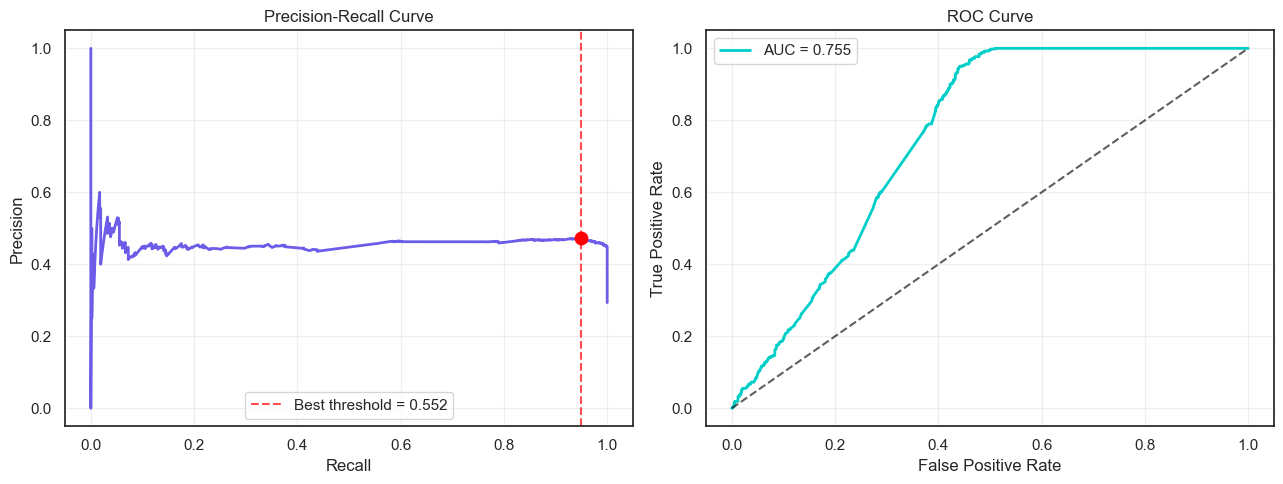

In [57]:
import numpy as np
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, classification_report

# ====================== Find Best Threshold ======================
prec_arr, rec_arr, thresholds = precision_recall_curve(y_test, y_pred_prob)

#  F1 calculation 
denom = prec_arr + rec_arr
f1_arr = np.zeros_like(prec_arr)
mask = denom > 0
f1_arr[mask] = 2 * prec_arr[mask] * rec_arr[mask] / denom[mask]

# Best threshold based on maximum F1 score
best_idx = np.argmax(f1_arr)
best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"Best threshold (F1-optimal): {best_thresh:.3f}\n")

# Apply threshold
y_pred_opt = (y_pred_prob >= best_thresh).astype(int)

# ====================== Evaluation ======================
print(classification_report(
    y_test, y_pred_opt,
    target_names=['Retained', 'Churned'],
    zero_division=0
))

print(f"ROC-AUC : {roc_auc_score(y_test, y_pred_prob):.4f}")

# ====================== Plots ======================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Precision-Recall Curve
axes[0].plot(rec_arr, prec_arr, color='#6C5CE7', linewidth=2)
axes[0].scatter(rec_arr[best_idx], prec_arr[best_idx], color='red', s=80, zorder=5)
axes[0].axvline(rec_arr[best_idx], color='red', linestyle='--', alpha=0.7,
                label=f'Best threshold = {best_thresh:.3f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_val = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#00CEC9', linewidth=2, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.7)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.5 Explainability – Coefficients & Odds Ratios

Feature Importance (Odds Ratios):
            feature  coefficient  odds_ratio
       total_events     0.108162    1.114229
       repeat_buyer     0.081289    1.084685
      is_high_value     0.061187    1.063098
      purchase_rate     0.038687    1.039445
         addtocarts     0.025492    1.025820
           monetary    -0.011783    0.988286
          frequency    -0.019742    0.980452
          cart_rate    -0.020237    0.979966
avg_score_per_event    -0.040381    0.960423
          purchases    -0.152804    0.858298
       buys_last30d    -0.989662    0.371702
      activity_span    -1.114225    0.328169
    is_recent_buyer    -1.726557    0.177896
     events_last30d    -3.994217    0.018422


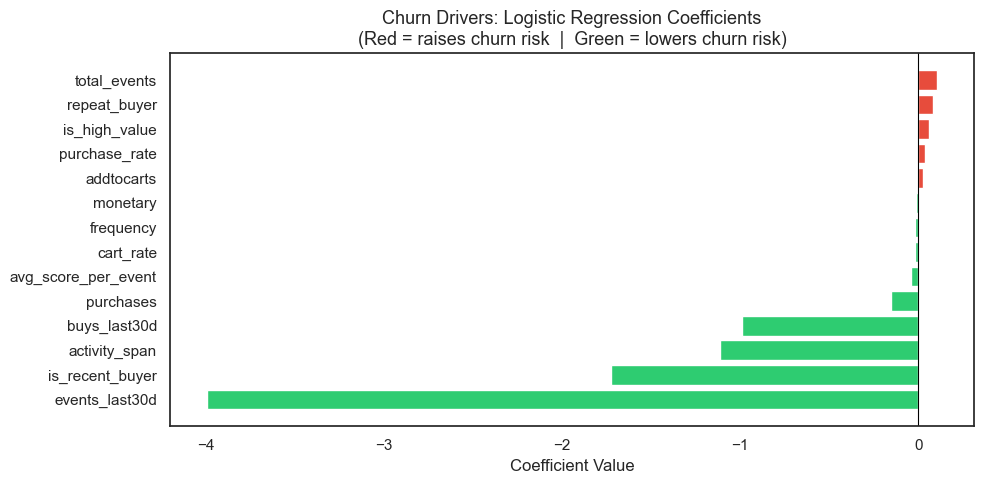

In [58]:
coef_df = pd.DataFrame({
    'feature'    : X_train.columns,
    'coefficient': lr_model.coef_[0],
    'odds_ratio' : np.exp(lr_model.coef_[0])
}).sort_values('odds_ratio', ascending=False)

print("Feature Importance (Odds Ratios):")
print(coef_df.to_string(index=False))

plot_df = coef_df.sort_values('coefficient')
colors  = ['#e74c3c' if c > 0 else '#2ecc71' for c in plot_df['coefficient']]

plt.figure(figsize=(10, 5))
plt.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(
    'Churn Drivers: Logistic Regression Coefficients\n'
    '(Red = raises churn risk  |  Green = lowers churn risk)',
    fontsize=13
)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 7. Business Insights & Final Framework

### Recommendation Engine
- The **hybrid SVD + category-content model** outperforms pure popularity by a significant margin on Precision@10 and NDCG@10.
- **Cold-start users** (new visitors with no history) automatically receive popularity-based recommendations — no manual fallback logic needed.
- Setting `alpha = 0.7` (70 % collaborative, 30 % content) strikes a good balance; tune this via A/B test.

### Churn Prediction
- **Recency** is consistently the strongest predictor of churn — the longer a user is absent, the higher their churn probability.
- **High-value users** (top 25 % by monetary score) churn at a lower rate; retention budget should prioritise borderline-recency high-value segments first.
- The **F1-optimal threshold** maximises the trade-off between catching churners (recall) and not over-triggering expensive retention campaigns (precision).

### Actionable Strategies
| Trigger | Action |
|---------|--------|
| Churn probability > 0.65 | Personalised re-engagement email + discount voucher |
| Recency > 15 days | Push top-10 personalised recommendations |
| Cart abandonment (addtocart, no transaction) | Abandoned-cart reminder within 24 h |
| New user (cold-start) | Onboarding email with top-10 popular items in preferred category |


In [60]:
print(" Project Complete — E-commerce Customer Intelligence Framework")
print()
print("  Dual-engine pipeline:")
print("    • Hybrid Recommendation  (SVD Collaborative + Category Content-Based)")
print("    • Churn Prediction        (Logistic Regression, RFM + Behavioural Features)")
print()
print("  Evaluation metrics available:")
print("    Recommendation : Precision@10, Recall@10, NDCG@10")
print("    Churn          : F1-optimal threshold, ROC-AUC, Classification Report")
print()
print("  Saved artefacts:")
print("    recommendation_model.pkl  — SVD factors + index maps")
print("    category_encoder.pkl      — OneHotEncoder for category features")

 Project Complete — E-commerce Customer Intelligence Framework

  Dual-engine pipeline:
    • Hybrid Recommendation  (SVD Collaborative + Category Content-Based)
    • Churn Prediction        (Logistic Regression, RFM + Behavioural Features)

  Evaluation metrics available:
    Recommendation : Precision@10, Recall@10, NDCG@10
    Churn          : F1-optimal threshold, ROC-AUC, Classification Report

  Saved artefacts:
    recommendation_model.pkl  — SVD factors + index maps
    category_encoder.pkl      — OneHotEncoder for category features
